In [14]:
from __future__ import annotations

import json
import os
import re
from collections.abc import Mapping
from functools import partial
from pathlib import Path
from types import MappingProxyType
from typing import Any, Optional

import numpy as np
import pandas as pd
from dask_image.imread import imread
from spatialdata import SpatialData
from spatialdata._logging import logger
from spatialdata.models import Image2DModel, ShapesModel, TableModel
from spatialdata.transformations.transformations import Identity, Scale
from xarray import DataArray

from spatialdata_io._constants._constants import VisiumKeys
from spatialdata_io._docs import inject_docs
from spatialdata_io.readers._utils._utils import _read_counts

__all__ = ["visium"]

# Modification of visium from spatialdata-io
def visium(
    path: str | Path,
    dataset_id: Optional[str] = None,
    counts_file: str = VisiumKeys.COUNTS_FILE,
    fullres_image_file: Optional[str | Path] = None,
    tissue_positions_file: Optional[str | Path] = None,
    scalefactors_file: Optional[str | Path] = None,
    imread_kwargs: Mapping[str, Any] = MappingProxyType({}),
    image_models_kwargs: Mapping[str, Any] = MappingProxyType({}),
    **kwargs: Any,
) -> SpatialData:
    """
    Read *10x Genomics* Visium formatted dataset.

    This function reads the following files:

        - ``(<dataset_id>_)`{vx.COUNTS_FILE!r}```: Counts and metadata file.
        - ``{vx.IMAGE_HIRES_FILE!r}``: High resolution image.
        - ``{vx.IMAGE_LOWRES_FILE!r}``: Low resolution image.
        - ``{vx.SCALEFACTORS_FILE!r}``: Scalefactors file.
        - ``{vx.SPOTS_FILE_1!r}`` (SpaceRanger 1) or ``{vx.SPOTS_FILE_2!r}`` (SpaceRanger 2):
            Spots positions file.
        - ``fullres_image_file``: large microscopy image used as input for space ranger.

    .. seealso::

        - `Space Ranger output <https://support.10xgenomics.com/spatial-gene-expression/software/pipelines/latest/output/overview>`_.

    Parameters
    ----------
    path
        Path to the directory containing the data.
    dataset_id
        Dataset identifier to name the constructed `SpatialData` elements. The reader will try to infer it from the
        ``{vx.COUNTS_FILE!r}`` file name. If the file name does not contain the dataset id, it will try to infer it from the metadata, it needs to be provided.
    counts_file
        Name of the counts file. Use only if counts is not in `h5` format.
    fullres_image_file
        Path to the full-resolution image.
    tissue_positions_file
        Path to the tissue positions file.
    scalefactors_file
        Path to the scalefactors file.
    imread_kwargs
        Keyword arguments passed to :func:`dask_image.imread.imread`.
    image_models_kwargs
        Keyword arguments passed to :class:`spatialdata.models.Image2DModel`.

    Returns
    -------
    :class:`spatialdata.SpatialData`
    """
    path = Path(path)
    imread_kwargs = dict(imread_kwargs)
    image_models_kwargs = dict(image_models_kwargs)
    # try to infer library_id from the counts file
    library_id = None
    try:
        patt = re.compile(f".*{VisiumKeys.COUNTS_FILE}")
        first_file = [i for i in os.listdir(path) if patt.match(i)][0]

        if f"_{VisiumKeys.COUNTS_FILE}" in first_file:
            library_id = first_file.replace(f"_{VisiumKeys.COUNTS_FILE}", "")
            counts_file = f"{library_id}_{VisiumKeys.COUNTS_FILE}"
        elif VisiumKeys.COUNTS_FILE == first_file:
            library_id = None
            counts_file = VisiumKeys.COUNTS_FILE
        else:
            raise ValueError(
                f"Cannot determine the library_id. Expecting a file with format (<library_id>_){VisiumKeys.COUNTS_FILE}"
                f". If the files have been renamed you may need to specify their file names (not their paths), with "
                f"some of the following arguments: `counts_file`, `fullres_image_file`, `tissue_positions_file`, "
                f"`scalefactors_file` arguments."
            )
    except IndexError as e:
        if counts_file is None:
            logger.error(
                f"{e}. \nError is due to the fact that the library id could not be found, if the counts file is `.mtx` (or else), Please provide a `counts_file`.",
            )
            raise e
    assert counts_file is not None

    if library_id is None and dataset_id is None:
        raise ValueError("Cannot determine the `library_id`. Please provide `dataset_id`.")

    if dataset_id is not None:
        if dataset_id != library_id and library_id is not None:
            logger.warning(
                f"`dataset_id: {dataset_id}` does not match `library_id: {library_id}`. `dataset_id: {dataset_id}` "
                f"will be used to build SpatialData."
            )
        library_id = dataset_id
    else:
        dataset_id = library_id
    assert dataset_id is not None

    # Yhe second element of the returned tuple is the full library as contained in the metadata of
    # VisiumKeys.COUNTS_FILE. For instance for the spatialdata-sandbox/visium dataset it is:
    #     spaceranger100_count_30458_ST8059048_mm10-3_0_0_premrna
    # We discard this value and use the one inferred from the filename of VisiumKeys.COUNTS_FILE, or the one provided by
    # the user in dataset_id
    adata, _ = _read_counts(path, counts_file=counts_file, library_id=library_id, **kwargs)

    # Read parquet file
    if (path / "spatial" / "tissue_positions.parquet").exists(): 
        read_coords = partial(pd.read_parquet)
        tissue_positions_file = path / "spatial" / "tissue_positions.parquet"
    else:
        raise ValueError(f"Cannot find `tissue_positions` file in `{path}`.")
    coords = read_coords(tissue_positions_file).set_index("barcode")

    # to handle spaceranger_version < 2.0.0, where no column names are provided
    # in fact, from spaceranger 2.0.0, the column names are provided in the file, and
    # are "pxl_col_in_fullres", "pxl_row_in_fullres" are inverted.
    # But, in the case of CytAssist, the column names provided but the image is flipped
    # so we need to invert the columns.
    if "in_tissue" not in coords.columns or "CytAssist" in str(fullres_image_file):
        coords.columns = ["in_tissue", "array_row", "array_col", "pxl_col_in_fullres", "pxl_row_in_fullres"]

    adata.obs = pd.merge(adata.obs, coords, how="left", left_index=True, right_index=True)
    coords = adata.obs[[VisiumKeys.SPOTS_X, VisiumKeys.SPOTS_Y]].values
    adata.obsm["spatial"] = coords
    adata.obs = pd.DataFrame(adata.obs)
    adata.obs.drop(columns=[VisiumKeys.SPOTS_X, VisiumKeys.SPOTS_Y], inplace=True)
    adata.obs["spot_id"] = np.arange(len(adata))
    adata.var_names_make_unique()
    if (path / "spatial" / VisiumKeys.SCALEFACTORS_FILE).exists() or (
        scalefactors_file is not None and (path / scalefactors_file).exists()
    ):
        scalefactors_file = (
            path / "spatial" / VisiumKeys.SCALEFACTORS_FILE if scalefactors_file is None else path / scalefactors_file
        )
        scalefactors = json.loads(scalefactors_file.read_bytes())

    transform_original = Identity()
    transform_lowres = Scale(
        np.array([scalefactors[VisiumKeys.SCALEFACTORS_LOWRES], scalefactors[VisiumKeys.SCALEFACTORS_LOWRES]]),
        axes=("y", "x"),
    )
    transform_hires = Scale(
        np.array([scalefactors[VisiumKeys.SCALEFACTORS_HIRES], scalefactors[VisiumKeys.SCALEFACTORS_HIRES]]),
        axes=("y", "x"),
    )
    shapes = {}
    circles = ShapesModel.parse(
        coords,
        geometry=0,
        radius=scalefactors["spot_diameter_fullres"] / 2.0,
        index=adata.obs["spot_id"].copy(),
        transformations={
            "global": transform_original,
            "downscaled_hires": transform_hires,
            "downscaled_lowres": transform_lowres,
        },
    )
    shapes[dataset_id] = circles
    adata.obs["region"] = dataset_id
    table = TableModel.parse(adata, region=dataset_id, region_key="region", instance_key="spot_id")

    images = {}
    if fullres_image_file is not None:
        fullres_image_file = path / Path(fullres_image_file)
        if fullres_image_file.exists():
            if "MAX_IMAGE_PIXELS" in imread_kwargs:
                from PIL import Image as ImagePIL

                ImagePIL.MAX_IMAGE_PIXELS = imread_kwargs.pop("MAX_IMAGE_PIXELS")
            full_image = imread(fullres_image_file, **imread_kwargs).squeeze().transpose(2, 0, 1)
            full_image = DataArray(full_image, dims=("c", "y", "x"))
            images[dataset_id + "_full_image"] = Image2DModel.parse(
                full_image,
                scale_factors=[2, 2, 2, 2],
                transformations={"global": transform_original},
                **image_models_kwargs,
            )
        else:
            logger.warning(f"File {fullres_image_file} does not exist, skipping...")

    if (path / VisiumKeys.IMAGE_HIRES_FILE).exists():
        image_hires = imread(path / VisiumKeys.IMAGE_HIRES_FILE, **imread_kwargs).squeeze().transpose(2, 0, 1)
        image_hires = DataArray(image_hires, dims=("c", "y", "x"))
        images[dataset_id + "_hires_image"] = Image2DModel.parse(
            image_hires, transformations={"downscaled_hires": Identity()}
        )
    if (path / VisiumKeys.IMAGE_LOWRES_FILE).exists():
        image_lowres = imread(path / VisiumKeys.IMAGE_LOWRES_FILE, **imread_kwargs).squeeze().transpose(2, 0, 1)
        image_lowres = DataArray(image_lowres, dims=("c", "y", "x"))
        images[dataset_id + "_lowres_image"] = Image2DModel.parse(
            image_lowres, transformations={"downscaled_lowres": Identity()}
        )

    return SpatialData(images=images, shapes=shapes, table=table)

import spatialdata as sd
import spatialdata_io
import spatialdata_plot
from napari_spatialdata import Interactive

from spatialdata.transformations import (
    Affine,
    Identity,
    MapAxis,
    Scale,
    Sequence,
    Translation,
    get_transformation,
    get_transformation_between_coordinate_systems,
    set_transformation,
)

import matplotlib.patches as patches
import spatialdata as sd
import spatialdata_plot
from matplotlib import pyplot as plt

In [3]:
filepath = "/home/chananchidas/topsecret/spaceranger/binned_outputs/"

In [28]:

sdata = visium(filepath + "square_002um/",
                               dataset_id = 'visium-hd')

INFO     reading /home/chananchidas/topsecret/spaceranger/binned_outputs/square_002um/filtered_feature_bc_matrix.h5


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/tmp/ipykernel_56823/3229578769.py:185: UserWarning: Converting `region_key: region` to categorical dtype.
  table = TableModel.parse(adata, region=dataset_id, region_key="region", instance_key="spot_id")


In [40]:
sdata

SpatialData object with:
├── Images
│     ├── 'visium-hd_hires_image': SpatialImage[cyx] (3, 2000, 1431)
│     └── 'visium-hd_lowres_image': SpatialImage[cyx] (3, 600, 429)
├── Shapes
│     └── 'visium-hd': GeoDataFrame shape: (8463264, 2) (2D shapes)
└── Table
      └── AnnData object with n_obs × n_vars = 8463264 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'spatialdata_attrs'
    obsm: 'spatial': AnnData (8463264, 18085)
with coordinate systems:
▸ 'downscaled_hires', with elements:
        visium-hd_hires_image (Images), visium-hd (Shapes)
▸ 'downscaled_lowres', with elements:
        visium-hd_lowres_image (Images), visium-hd (Shapes)
▸ 'global', with elements:
        visium-hd (Shapes)

#### Q1.  Why does `get_transformation` not show the link to `'global'`, but `get_transformation_between_coordinate_systems` works?

Using the `downscaled_hires` coordinate system and the associated image.

In [30]:
print(get_transformation(sdata.images["visium-hd_hires_image"], get_all=True))

{'downscaled_hires': Identity }


In [31]:
print(get_transformation_between_coordinate_systems(sdata, "downscaled_hires", "global"))
print("=========")
print(get_transformation_between_coordinate_systems(sdata, sdata.images["visium-hd_hires_image"], "global"))

Sequence 
    Scale (y, x)
        [19.4454999 19.4454999]
    Identity 
Sequence 
    Identity 
    Scale (y, x)
        [19.4454999 19.4454999]
    Identity 


#### Q2. Is the bounding box query limited to a coordinate system with images?

Let's define the following bounding box.

In [58]:
bb_xmin = 100
bb_ymin = 100
bb_w = 200
bb_h = 200
bb_xmax = bb_xmin + bb_w
bb_ymax = bb_ymin + bb_h

Lowres image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


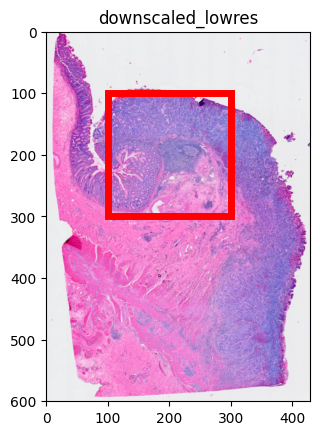

In [59]:
f, ax = plt.subplots()
sdata.pl.render_images().pl.show(coordinate_systems="downscaled_lowres", ax=ax)
rect = patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)

In [60]:
sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="downscaled_lowres"
)

/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/spatialdata/_utils.py:212: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  obs[column] = c


SpatialData object with:
├── Images
│     └── 'visium-hd_lowres_image': SpatialImage[cyx] (3, 200, 200)
├── Shapes
│     └── 'visium-hd': GeoDataFrame shape: (3015947, 2) (2D shapes)
└── Table
      └── AnnData object with n_obs × n_vars = 3015947 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'spatialdata_attrs'
    obsm: 'spatial': AnnData (3015947, 18085)
with coordinate systems:
▸ 'downscaled_hires', with elements:
        visium-hd (Shapes)
▸ 'downscaled_lowres', with elements:
        visium-hd_lowres_image (Images), visium-hd (Shapes)
▸ 'global', with elements:
        visium-hd (Shapes)

Hi-res image

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


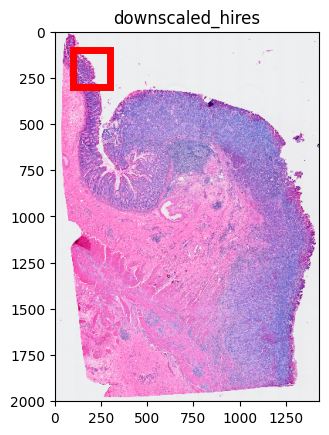

In [61]:
f, ax = plt.subplots()
sdata.pl.render_images().pl.show(coordinate_systems="downscaled_hires", ax=ax)
rect = patches.Rectangle((bb_xmin, bb_ymin), bb_w, bb_h, linewidth=5, edgecolor="red", facecolor="none")
ax.add_patch(rect)

In [67]:
sdata_subset = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="downscaled_hires"
)

sdata_subset

/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/spatialdata/_utils.py:212: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  obs[column] = c


Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


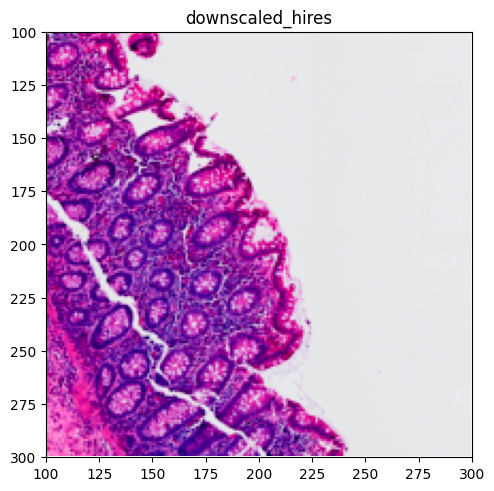

In [77]:
sdata_subset.pl.render_images().pl.show(coordinate_systems="downscaled_hires")

For the 'global' coordinate system, check the bounds

In [78]:
# Get min and max coordinates of sdata
print(sdata.shapes["visium-hd"].geometry.bounds)

# GeometryArray object
print(sdata.shapes["visium-hd"].geometry.bounds.minx.min())
print(sdata.shapes["visium-hd"].geometry.bounds.miny.min())
print(sdata.shapes["visium-hd"].geometry.bounds.minx.max())
print(sdata.shapes["visium-hd"].geometry.bounds.miny.max())

sdata_subset = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[5000, 3200],
    max_coordinate=[6000, 3400],
    target_coordinate_system="global"
)

                 minx          miny          maxx          maxy
spot_id                                                        
0        22861.799289  18653.933121  22861.799289  18653.933121
1        12998.974858   4173.844054  12998.974858   4173.844054
2        11303.749638   9357.210623  11303.749638   9357.210623
3        23261.495065   7473.961376  23261.495065   7473.961376
4        17437.523119  25050.344425  17437.523119  25050.344425
...               ...           ...           ...           ...
8463259  25714.246935  10537.358904  25714.246935  10537.358904
8463260  17885.585654  10830.018823  17885.585654  10830.018823
8463261  14688.979500  14869.022903  14688.979500  14869.022903
8463262   5945.025737   3924.868792   5945.025737   3924.868792
8463263  11978.575861  16166.675470  11978.575861  16166.675470

[8463264 rows x 4 columns]
4856.105066963867
3130.4978693014637
27897.786970379668
27468.192609739195


/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/spatialdata/_utils.py:212: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  obs[column] = c


In [87]:
sdata_subset = sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[4800, 3100],
    max_coordinate=[27897, 5000],
    target_coordinate_system="global")

/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/spatialdata/_utils.py:212: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  obs[column] = c


In [89]:
sdata_subset

SpatialData object with:
├── Shapes
│     └── 'visium-hd': GeoDataFrame shape: (716978, 2) (2D shapes)
└── Table
      └── AnnData object with n_obs × n_vars = 716978 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'spatialdata_attrs'
    obsm: 'spatial': AnnData (716978, 18085)
with coordinate systems:
▸ 'downscaled_hires', with elements:
        visium-hd (Shapes)
▸ 'downscaled_lowres', with elements:
        visium-hd (Shapes)
▸ 'global', with elements:
        visium-hd (Shapes)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


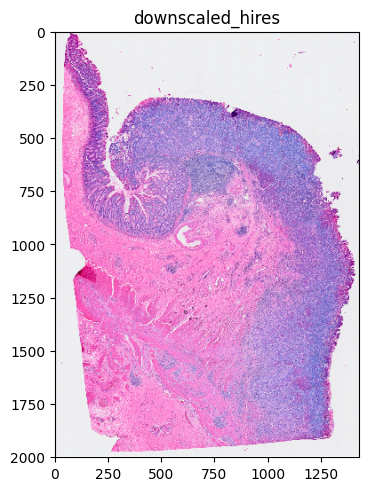

In [92]:
sdata.pl.render_images().pl.show(coordinate_systems="downscaled_hires")

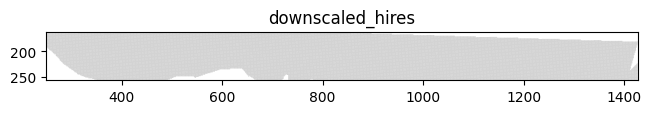

In [93]:
sdata_subset.pl.render_shapes().pl.show(coordinate_systems="downscaled_hires")

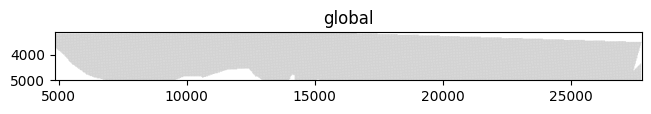

In [88]:
sdata_subset.pl.render_shapes().pl.show(coordinate_systems="global")

In [34]:
sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="downscaled_lowres"
)

/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/spatialdata/_utils.py:212: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  obs[column] = c


SpatialData object with:
├── Images
│     └── 'visium-hd_lowres_image': SpatialImage[cyx] (3, 200, 179)
├── Shapes
│     └── 'visium-hd': GeoDataFrame shape: (2264301, 2) (2D shapes)
└── Table
      └── AnnData object with n_obs × n_vars = 2264301 × 18085
    obs: 'in_tissue', 'array_row', 'array_col', 'spot_id', 'region'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'spatial', 'spatialdata_attrs'
    obsm: 'spatial': AnnData (2264301, 18085)
with coordinate systems:
▸ 'downscaled_hires', with elements:
        visium-hd (Shapes)
▸ 'downscaled_lowres', with elements:
        visium-hd_lowres_image (Images), visium-hd (Shapes)
▸ 'global', with elements:
        visium-hd (Shapes)

In [35]:
sdata.query.bounding_box(
    axes=["x", "y"],
    min_coordinate=[bb_xmin, bb_ymin],
    max_coordinate=[bb_xmax, bb_ymax],
    target_coordinate_system="global"
)

AssertionError: elements_dict must contain at least one dict which contains at least one element

In [33]:
import math

import matplotlib.pyplot as plt
import spatialdata_plot
from spatialdata.datasets import raccoon
from spatialdata.transformations import (
    Affine,
    Identity,
    MapAxis,
    Scale,
    Sequence,
    Translation,
    get_transformation,
    get_transformation_between_coordinate_systems,
    set_transformation,
)

In [38]:
get_transformation(sdata.images['visium-hd_hires_image'], "downscaled_hires")

Identity 

In [46]:
get_transformation_between_coordinate_systems(sdata, sdata.images["visium-hd_lowres_image"], "global")
print(get_transformation_between_coordinate_systems(sdata, "downscaled_hires", "global"))


Sequence 
    Identity 
    Scale (y, x)
        [64.81833301 64.81833301]
    Identity 

In [29]:
print(sdata.coordinate_systems)

['global', 'downscaled_lowres', 'downscaled_hires']


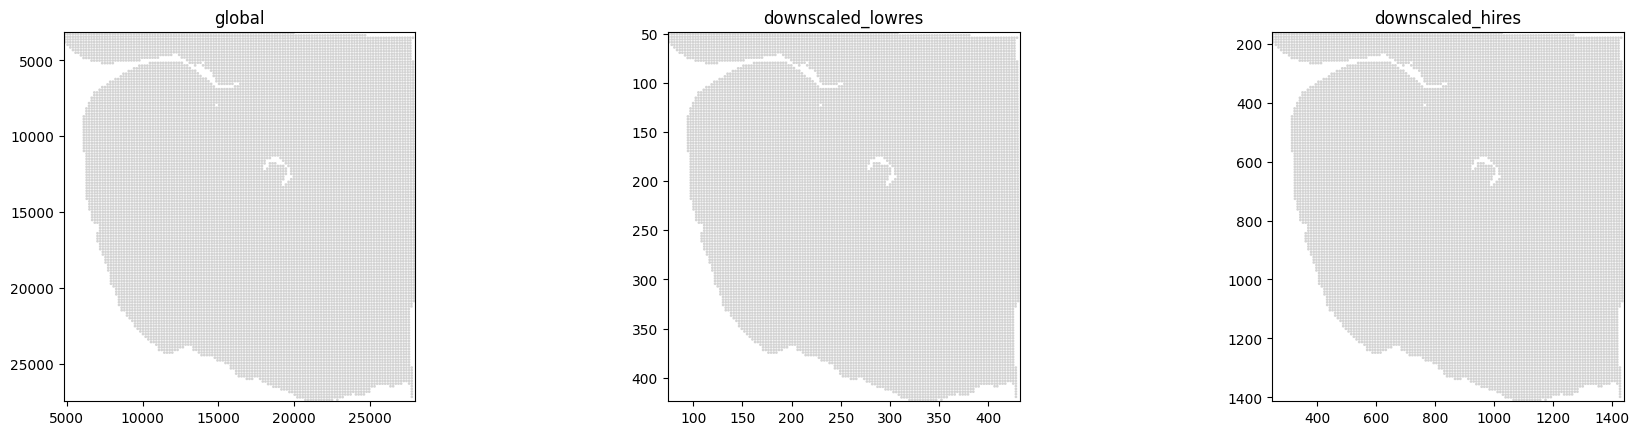

In [28]:
sdata.pl.render_shapes().pl.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


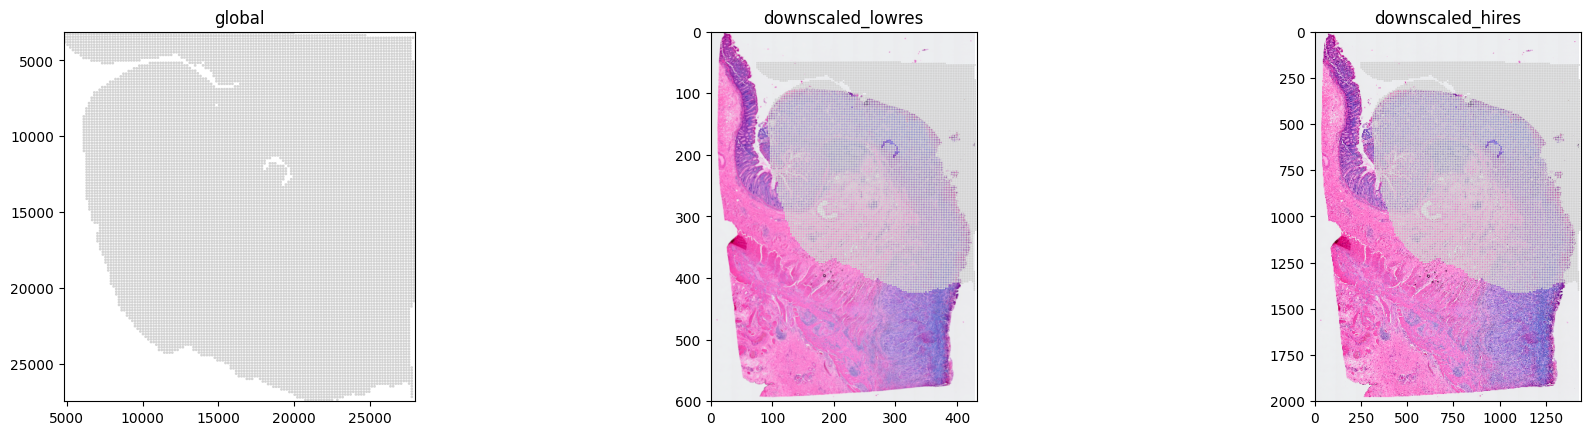

In [27]:
sdata.pl.render_images().pl.render_shapes().pl.show()

In [26]:
sdata.pp.get_elements("lol")

ValueError: Element 'lol' not found. Valid choices are:

coordinate_systems
├ global
├ downscaled_lowres
├ downscaled_hires

images
├ visium-hd_hires_image
├ visium-hd_lowres_image

labels
├ 

shapes
├ visium-hd

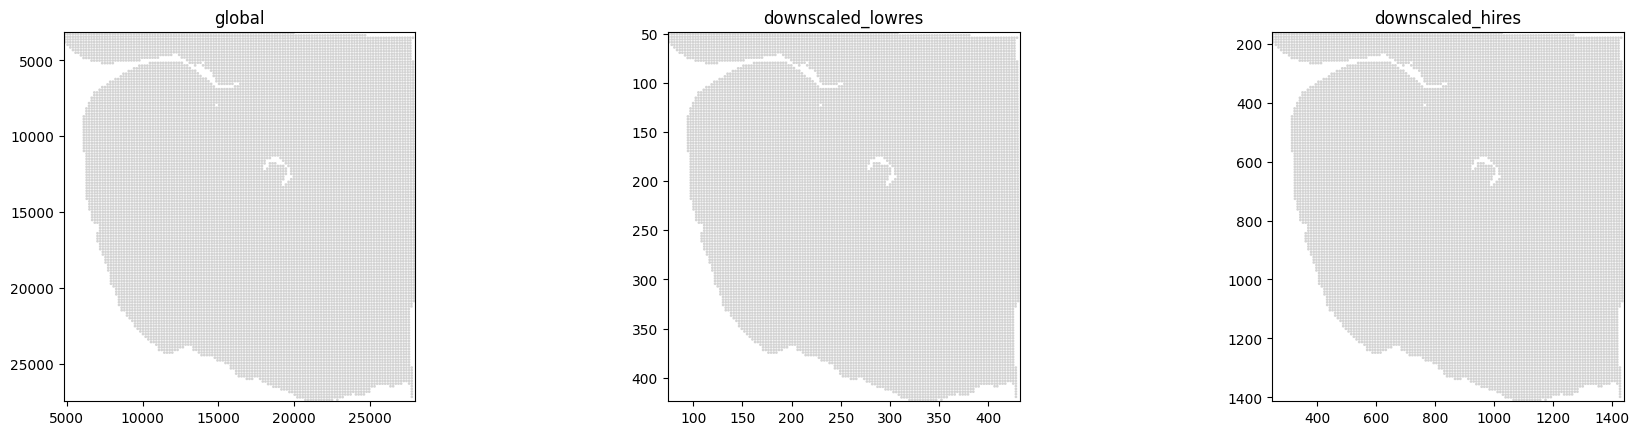

In [25]:
(sdata.pp.get_elements("visium-hd").pl.render_images().pl.render_shapes().pl.show())

## Code dump

In [ ]:
import scanpy as sc

from __future__ import annotations

import json
from pathlib import Path, PurePath
from typing import BinaryIO, Literal

import anndata.utils
import h5py
import numpy as np
import pandas as pd
from anndata import (
    AnnData,
    read_csv,
    read_excel,
    read_h5ad,
    read_hdf,
    read_loom,
    read_mtx,
    read_text,
)
from matplotlib.image import imread

from scanpy import logging as logg
#from scanpy._compat import old_positionals
#from scanpy._settings import settings
#from scanpy._utils import Empty, _empty

In [ ]:
# Modification of read_visium from scanpy
def read_visium(
    path: Path | str,
    genome: str | None = None,
    *,
    count_file: str = "filtered_feature_bc_matrix.h5",
    library_id: str | None = None,
    load_images: bool | None = True,
    source_image_path: Path | str | None = None,
) -> AnnData:

    path = Path(path)
    adata = sc.read_10x_h5(path / count_file, genome=genome)

    adata.uns["spatial"] = dict()

    from h5py import File

    with File(path / count_file, mode="r") as f:
        attrs = dict(f.attrs)
    if library_id is None:
        library_id = str(attrs.pop("library_ids")[0], "utf-8")

    adata.uns["spatial"][library_id] = dict()

    if load_images:
        files = dict(
            tissue_positions_file=path / "spatial/tissue_positions.parquet",
            scalefactors_json_file=path / "spatial/scalefactors_json.json",
            hires_image=path / "spatial/tissue_hires_image.png",
            lowres_image=path / "spatial/tissue_lowres_image.png",
        )

        # check if files exists, continue if images are missing
        for f in files.values():
            if not f.exists():
                if any(x in str(f) for x in ["hires_image", "lowres_image"]):
                    logg.warning(
                        f"You seem to be missing an image file.\n"
                        f"Could not find '{f}'."
                    )
                else:
                    raise OSError(f"Could not find '{f}'")

        adata.uns["spatial"][library_id]["images"] = dict()
        for res in ["hires", "lowres"]:
            try:
                adata.uns["spatial"][library_id]["images"][res] = imread(
                    str(files[f"{res}_image"])
                )
            except Exception:
                raise OSError(f"Could not find '{res}_image'")

        # read json scalefactors
        adata.uns["spatial"][library_id]["scalefactors"] = json.loads(
            files["scalefactors_json_file"].read_bytes()
        )

        adata.uns["spatial"][library_id]["metadata"] = {
            k: (str(attrs[k], "utf-8") if isinstance(attrs[k], bytes) else attrs[k])
            for k in ("chemistry_description", "software_version")
            if k in attrs
        }
        
        
        # read coordinates (parquet)
        positions = pd.read_parquet(
            files["tissue_positions_file"]
        ).set_index('barcode')
        
        # pxl_row and pxl_cols are swapped compared to normal
        positions.columns = [
            "in_tissue",
            "array_row",
            "array_col",
            "pxl_row_in_fullres",
            "pxl_col_in_fullres",
        ]

        adata.obs = adata.obs.join(positions, how="left")

        adata.obsm["spatial"] = adata.obs[
            ["pxl_row_in_fullres", "pxl_col_in_fullres"]
        ].to_numpy()
        adata.obs.drop(
            columns=["pxl_row_in_fullres", "pxl_col_in_fullres"],
            inplace=True,
        )

        # put image path in uns
        if source_image_path is not None:
            # get an absolute path
            source_image_path = str(Path(source_image_path).resolve())
            adata.uns["spatial"][library_id]["metadata"]["source_image_path"] = str(
                source_image_path
            )

    return adata

In [8]:
pd.read_csv("/home/chananchidas/spotless-benchmark/data/raw_data/liver_guilliams2022/mouseStSt_visium/JBO01/tissue_positions_list.csv",
            compression = 'gzip', header=None, index_col=0)


,1,2,3,4,5
0,,,,,
ACGCCTGACACGCGCT-1,0,0,0,506,471
TACCGATCCAACACTT-1,0,1,1,534,488
ATTAAAGCGGACGAGC-1,0,0,2,506,504
GATAAGGGACGATTAG-1,0,1,3,534,521
GTGCAAATCACCAATA-1,0,0,4,506,537
...,...,...,...,...,...
GAACGTTTGTATCCAC-1,0,77,123,2706,2498
ATTGAATTCCCTGTAG-1,0,76,124,2677,2514
TACCTCACCAATTGTA-1,0,77,125,2706,2530


In [9]:
pd.read_parquet("/home/chananchidas/topsecret/spaceranger/binned_outputs/square_048um/spatial/tissue_positions.parquet")

,barcode,in_tissue,array_row,array_col,pxl_row_in_fullres,pxl_col_in_fullres
0,s_048um_00000_00000-1,0,0,0,27827.440710,3153.367452
1,s_048um_00000_00001-1,0,0,1,27828.189682,3328.631423
2,s_048um_00000_00002-1,1,0,2,27828.938662,3503.897463
3,s_048um_00000_00003-1,0,0,3,27829.687652,3679.165571
4,s_048um_00000_00004-1,0,0,4,27830.436650,3854.435748
...,...,...,...,...,...,...
19595,s_048um_00139_00135-1,0,139,135,3563.846380,26929.197649
19596,s_048um_00139_00136-1,0,139,136,3564.451932,27104.537737
19597,s_048um_00139_00137-1,0,139,137,3565.057491,27279.879894
19598,s_048um_00139_00138-1,0,139,138,3565.663058,27455.224121


In [ ]:
sdata_sc = read_visium(filepath + "square_002um/")

/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")
/home/chananchidas/miniconda3/envs/spatialdata/lib/python3.9/site-packages/anndata/_core/anndata.py:1908: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


In [ ]:
sdata_sc